In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def get_bandit_function(k):
    '''
    Parameters:
    k : int - number of armes for the bandit

    Returns:
    callable - the bandit function bandit_function which can be called via bandit_function(action)
    which returns a random reward for selecting the action-th arm of the bandit
    list - list of centers of the different arms of the bandits
    '''

    # draw k gaussian random numbers q_i as centers
    # define a function which expects a parameter action and returns a random number from N(q_i,1)
    # return that function and a list of the q_i's

    q_stern = np.random.normal(0, 1, size=k)

    def bandit_function(action):
        # action = Hebel
        if action < 0 or action >= k:  
            raise ValueError("invalid")

        reward = np.random.normal(q_stern[action], 1)
        return reward
        
    return bandit_function, list(q_stern)

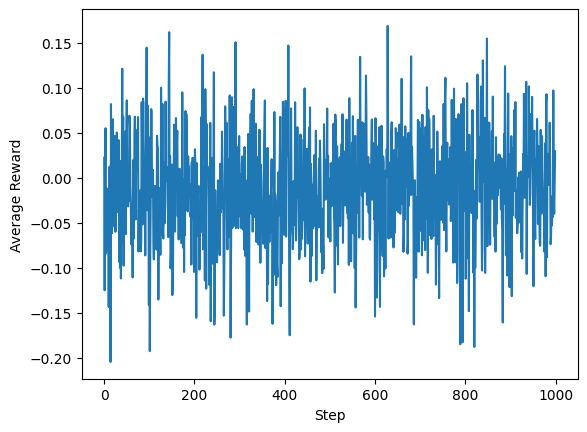

In [4]:
k = 10
Ne = 500
N = 1000

avg_rewards = np.zeros(N) # speichern der Rewards

for episode in range(Ne):
    bandit_function, _ = get_bandit_function(k)

    for t in range(N):
        action = np.random.randint(0,k)
        reward = bandit_function(action)
        avg_rewards[t] += reward

avg_rewards /= Ne # Mittelwert über alle Epochen

# Plot
plt.plot(avg_rewards)
plt.xlabel("Step")
plt.ylabel("Average Reward")
plt.show()

In [5]:
def update_Q_and_N(Q, N, r, a):
    N[a] += 1
    Q[a] = Q[a] + (1 / N[a]) * (r - Q[a])

    return Q, N

In [7]:
def eps_greedy(bandit_function, eps, Q_0=0, k=10, N=1000):
    '''
    Parameters:
    bandit_function : callable - function of the k-armed bandit, where bandit_function(action)
    returns the reward of pulling the k-th lever (action = 0,1,..,k-1)
    eps : float - epsilon of the eps-greedy strategy. Chooses with probability eps the
    exploration and with 1-eps the greedy strategy
    Q_0 : float - initial vale for the expected reward
    k : int - number of arms of the bandit
    1N : int - number of rounds to play
    
    Returns:
    np.array - Array of the encountered rewards in sequence
    np.array - Array of the expected Q values
    np.array - Array of times, the different levers have been pulled
    '''
    
    Q = np.ones(k) * Q_0 
    N_counts = np.zeros(k)

    rewards = np.zeros(N)
    Q_history = np.zeros((N, k))
    N_history = np.zeros((N, k))

    for t in range(N):
        if np.random.rand() < eps:
            action = np.random.randint(0, k)
        else:
            max_Q = np.max(Q)
            candidates = np.where(Q == max_Q)[0]
            action = np.random.choice(candidates)

        reward = bandit_function(action)

        Q, N_counts = update_Q_and_N(Q, N_counts, reward, action)

        rewards[t] = reward
        Q_history[t] = Q
        N_history[t] = N_counts

    return rewards, Q_history, N_history
        

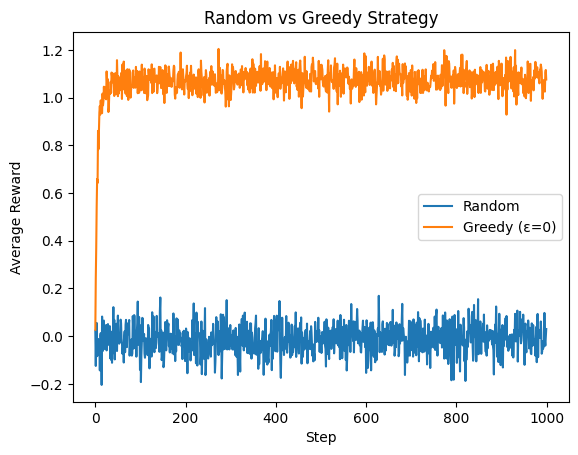

In [8]:
Ne = 500
N = 1000
k = 10

all_rewards = np.zeros((Ne, N))

for episode in range(Ne):
    bandit_function, _ = get_bandit_function(k)

    rewards, Q_hist, N_hist = eps_greedy(
        bandit_function=bandit_function,
        eps=0,        
        Q_0=0,
        k=k,
        N=N
    )

    all_rewards[episode] = rewards

avg_rewards_greedy = np.mean(all_rewards, axis=0)

plt.plot(avg_rewards, label="Random")
plt.plot(avg_rewards_greedy, label="Greedy (ε=0)")

plt.xlabel("Step")
plt.ylabel("Average Reward")
plt.title("Random vs Greedy Strategy")
plt.legend()
plt.show()

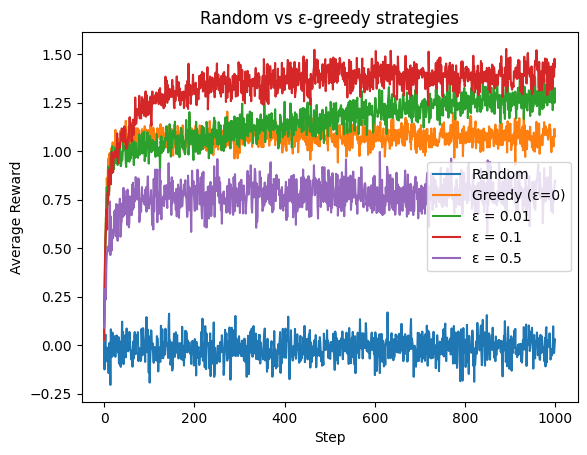

In [9]:
eps_values = [0.01, 0.1, 0.5]

results = {}
Ne = 500
N = 1000
k = 10

for eps in eps_values:
    all_rewards = np.zeros((Ne, N))

    for episode in range(Ne):
        bandit_function, _ = get_bandit_function(k)

        rewards, _, _ = eps_greedy(
            bandit_function=bandit_function,
            eps=eps,
            Q_0=0,
            k=k,
            N=N
        )

        all_rewards[episode] = rewards

    results[eps] = np.mean(all_rewards, axis=0)

plt.plot(avg_rewards, label="Random")
plt.plot(avg_rewards_greedy, label="Greedy (ε=0)")

for eps in eps_values:
    plt.plot(results[eps], label=f"ε = {eps}")

plt.xlabel("Step")
plt.ylabel("Average Reward")
plt.title("Random vs ε-greedy strategies")
plt.legend()
plt.show()

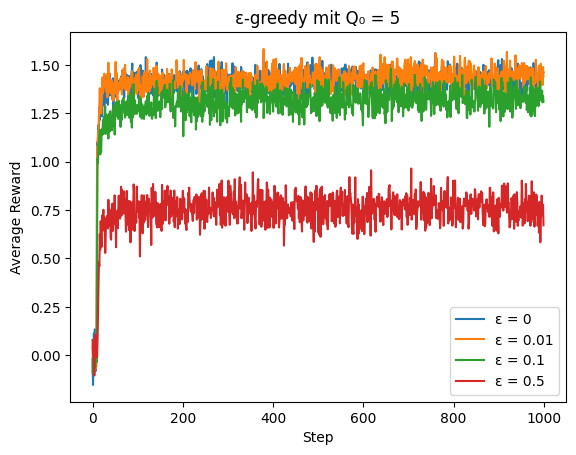

In [10]:
eps_values = [0, 0.01, 0.1, 0.5]

results_q0_5 = {}
Ne = 500
N = 1000
k = 10

for eps in eps_values:
    all_rewards = np.zeros((Ne, N))

    for episode in range(Ne):
        bandit_function, _ = get_bandit_function(k)

        rewards, _, _ = eps_greedy(
            bandit_function=bandit_function,
            eps=eps,
            Q_0=5,   
            k=k,
            N=N
        )

        all_rewards[episode] = rewards

    results_q0_5[eps] = np.mean(all_rewards, axis=0)

plt.figure()

for eps in eps_values:
    plt.plot(results_q0_5[eps], label=f"ε = {eps}")

plt.xlabel("Step")
plt.ylabel("Average Reward")
plt.title("ε-greedy mit Q₀ = 5")
plt.legend()
plt.show()

In [11]:
def update_Q_and_N_alpha(Q, N, r, a, alpha):
    N[a] += 1
    Q[a] = Q[a] + alpha * (r - Q[a])
    return Q, N

def eps_greedy_alpha(bandit_function, eps, alpha, Q_0=0, k=10, N=1000):
    Q = np.ones(k) * Q_0
    N_counts = np.zeros(k)

    rewards = np.zeros(N)

    for t in range(N):
        if np.random.rand() < eps:
            action = np.random.randint(0, k)
        else:
            max_Q = np.max(Q)
            candidates = np.where(Q == max_Q)[0]
            action = np.random.choice(candidates)

        reward = bandit_function(action)
        Q, N_counts = update_Q_and_N_alpha(Q, N_counts, reward, action, alpha)

        rewards[t] = reward

    return rewards

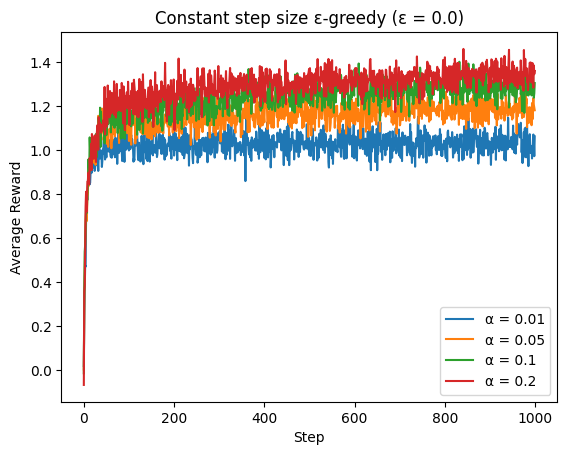

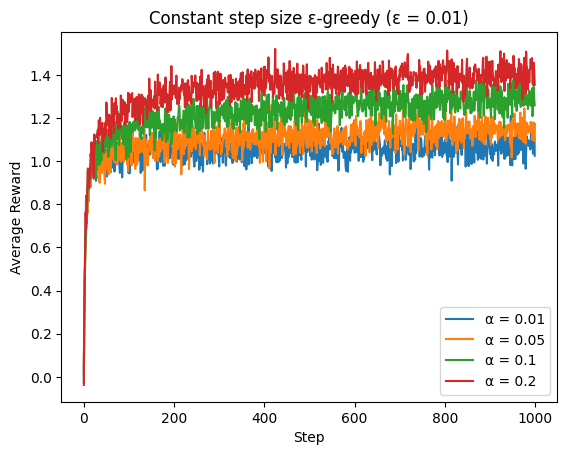

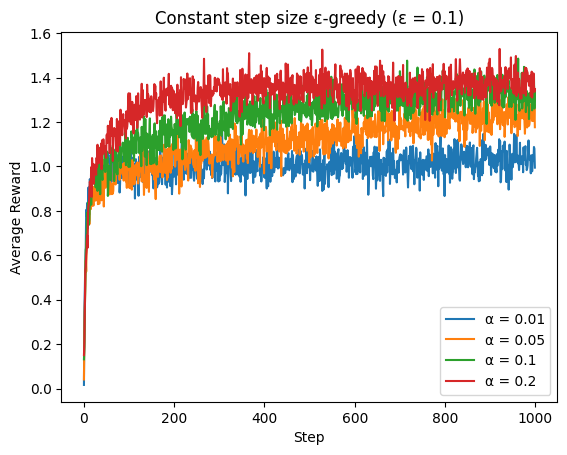

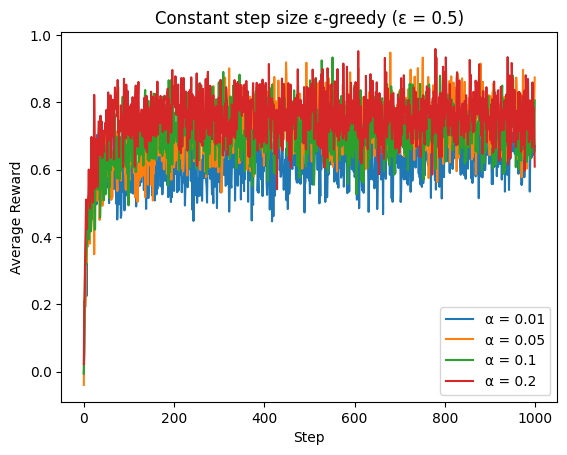

In [12]:
alphas = [0.01, 0.05, 0.1, 0.2]
eps_values = [0.0, 0.01, 0.1, 0.5]

results_alpha = {}

Ne = 500
N = 1000
k = 10
results = {}

for eps in eps_values:
    results[eps] = {}

    for alpha in alphas:
        all_rewards = np.zeros((Ne, N))

        for episode in range(Ne):
            bandit_function, _ = get_bandit_function(k)

            rewards = eps_greedy_alpha(
                bandit_function=bandit_function,
                eps=eps,
                alpha=alpha,
                Q_0=0,
                k=k,
                N=N
            )

            all_rewards[episode] = rewards

        results[eps][alpha] = np.mean(all_rewards, axis=0)

for eps in eps_values:
    plt.figure()

    for alpha in alphas:
        plt.plot(results[eps][alpha], label=f"α = {alpha}")

    plt.xlabel("Step")
    plt.ylabel("Average Reward")
    plt.title(f"Constant step size ε-greedy (ε = {eps})")
    plt.legend()

    plt.savefig("name.png", dpi=300, bbox_inches="tight")
    plt.show()

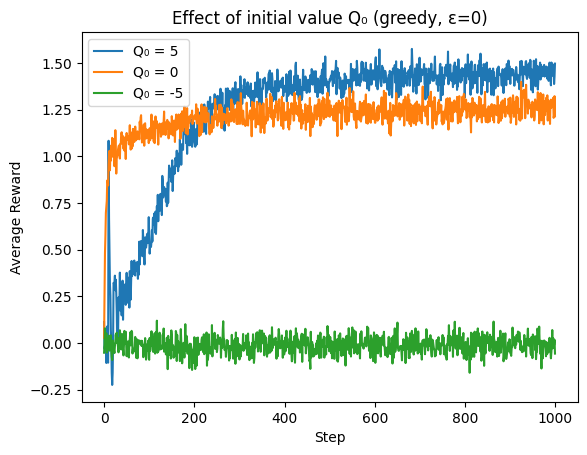

In [14]:
# Anfangswert Q_0 Plot
Q0_values = [5, 0, -5]

results_q0 = {}

Ne = 500
N = 1000
k = 10

for Q0 in Q0_values:
    all_rewards = np.zeros((Ne, N))

    for episode in range(Ne):
        bandit_function, _ = get_bandit_function(k)

        rewards = eps_greedy_alpha(
            bandit_function=bandit_function,
            eps=0,          
            alpha=0.1,      
            Q_0=Q0,
            k=k,
            N=N
        )

        all_rewards[episode] = rewards

    results_q0[Q0] = np.mean(all_rewards, axis=0)

plt.figure()

for Q0 in Q0_values:
    plt.plot(results_q0[Q0], label=f"Q₀ = {Q0}")

plt.xlabel("Step")
plt.ylabel("Average Reward")
plt.title("Effect of initial value Q₀ (greedy, ε=0)")
plt.legend()
plt.show()

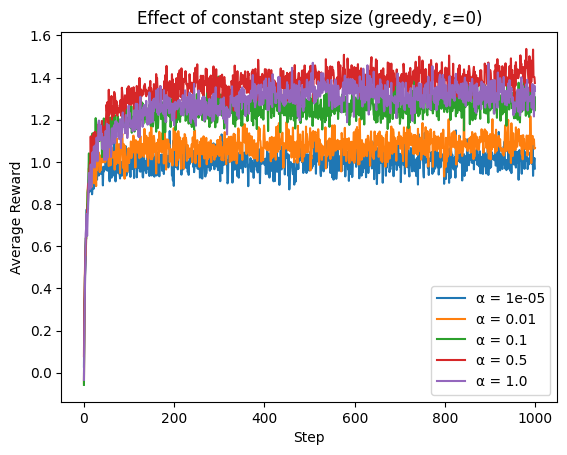

In [16]:
# Alphas neu
alphas = [1e-5, 0.01, 0.1, 0.5, 1.0]

Ne = 500
N = 1000
k = 10

results = {}

eps = 0 

for alpha in alphas:
    all_rewards = np.zeros((Ne, N))

    for episode in range(Ne):
        bandit_function, _ = get_bandit_function(k)

        rewards = eps_greedy_alpha(
            bandit_function=bandit_function,
            eps=eps,
            alpha=alpha,
            Q_0=0,
            k=k,
            N=N
        )

        all_rewards[episode] = rewards

    results[alpha] = np.mean(all_rewards, axis=0)

plt.figure()

for alpha in alphas:
    plt.plot(results[alpha], label=f"α = {alpha}")

plt.xlabel("Step")
plt.ylabel("Average Reward")
plt.title("Effect of constant step size (greedy, ε=0)")
plt.legend()

plt.show()